In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [3]:
from google.colab import files
uploaded = files.upload()

Saving toxicity dataset.csv to toxicity dataset.csv


In [4]:
import pandas as pd

df = pd.read_csv("toxicity dataset.csv")

print(df.head())
print(df.shape)

   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C  MDEO-22     Class  
0      

In [5]:
print(df.info())
print(df.describe())
print(df['Class'].value_counts())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 1204 entries, MATS3v to Class
dtypes: float64(1003), int64(200), object(1)
memory usage: 1.6+ MB
None
           MATS3v    nHBint10      MATS3s      MATS3p  nHBDon_Lipinski  \
count  171.000000  171.000000  171.000000  171.000000       171.000000   
mean    -0.031244    0.315789   -0.001001   -0.061501         0.994152   
std      0.063559    0.762918    0.063928    0.072891         1.108773   
min     -0.311500    0.000000   -0.184600   -0.348500         0.000000   
25%     -0.066700    0.000000   -0.036000   -0.099550         0.000000   
50%     -0.032500    0.000000   -0.002000   -0.059400         1.000000   
75%      0.004850    0.000000    0.029000   -0.017100         2.000000   
max      0.141100    4.000000    0.218100    0.129000         6.000000   

        minHBint8      MATS3e      MATS3c   minHBint2      MATS3m  ...  \
count  171.000000  171.000000  171.000000  171.000000  171.000000  ...   
me

/tmp/ipykernel_193/2376798456.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Class", palette="viridis")


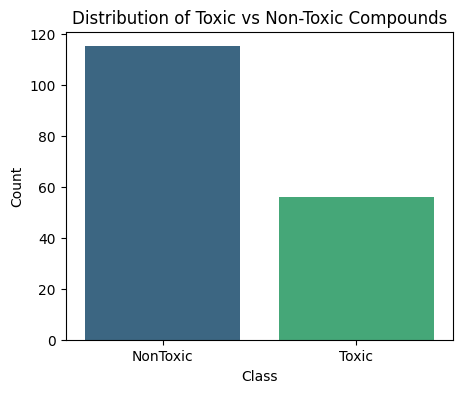

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# visualize distribution of the target variable
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Class", palette="viridis")
plt.title("Distribution of Toxic vs Non-Toxic Compounds")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [23]:
# check missing values
missing_values = df.isnull().sum()

# print only columns that contain missing values
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [24]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (171, 1203)
Target shape: (171,)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(y_train_resampled.value_counts())

Class distribution after SMOTE:
Class
0    91
1    91
Name: count, dtype: int64


In [37]:
from sklearn.ensemble import RandomForestClassifier

feature_selector = RandomForestClassifier(n_estimators=200, random_state=42)

feature_selector.fit(X_train_resampled, y_train_resampled)

importances = feature_selector.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# select top 30 features
top_features = feature_importance_df.head(30)["Feature"]

X_train_selected = X_train_resampled[top_features]
X_test_selected = X_test[top_features]

print("Selected features:", len(top_features))

Selected features: 30


In [38]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

model.fit(X_train_selected, y_train_resampled)

RandomForestClassifier(n_estimators=300, random_state=42)

In [32]:
df["Class"] = df["Class"].map({
    "NonToxic": 0,
    "Toxic": 1
})

In [33]:
print(df["Class"].value_counts())

Class
0    115
1     56
Name: count, dtype: int64


In [34]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [39]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train_selected,
    y_train_resampled,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Average CV score:", cv_scores.mean())

Cross-validation F1 scores: [0.58823529 0.72222222 0.8        0.94736842 0.94736842]
Average CV score: 0.8010388716890265


In [40]:
y_pred = model.predict(X_test_selected)

In [41]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.88      0.79        24
           1       0.50      0.27      0.35        11

    accuracy                           0.69        35
   macro avg       0.61      0.57      0.57        35
weighted avg       0.65      0.69      0.65        35


Confusion Matrix:

[[21  3]
 [ 8  3]]
